In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [71]:
df=pd.read_excel("premiums.xlsx")
df.head(3)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164


In [72]:
df.shape

(50000, 13)

In [73]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [74]:
df.columns = df.columns.str.replace(" ", "_").str.lower()
df.head(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164


In [75]:
df.isna().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

### Handle NA value 

In [76]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Duplicate handling

In [77]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [78]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


In [79]:
df[df['number_of_dependants'] < 0].shape

(72, 13)

In [80]:
df[df.number_of_dependants < 0]['number_of_dependants'].unique()

array([-3, -1])

In [81]:
df['number_of_dependants'] = abs(df['number_of_dependants'])

In [82]:
df[df['number_of_dependants'] < 0].shape

(0, 13)

In [84]:
df['number_of_dependants'].describe()

count    49976.000000
mean         1.717284
std          1.491953
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

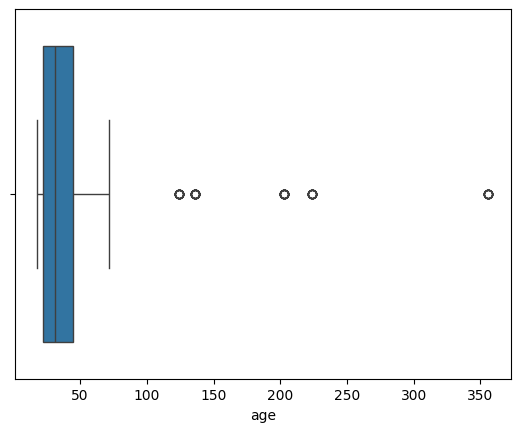

In [85]:
sns.boxplot(x=df['age'])
plt.show()

In [86]:
numeric_columns = df.select_dtypes(include=np.number).columns

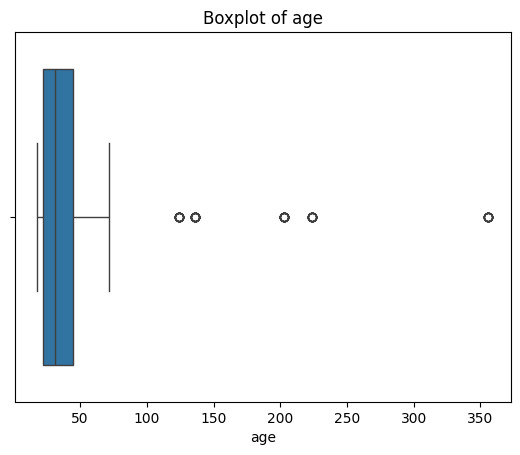

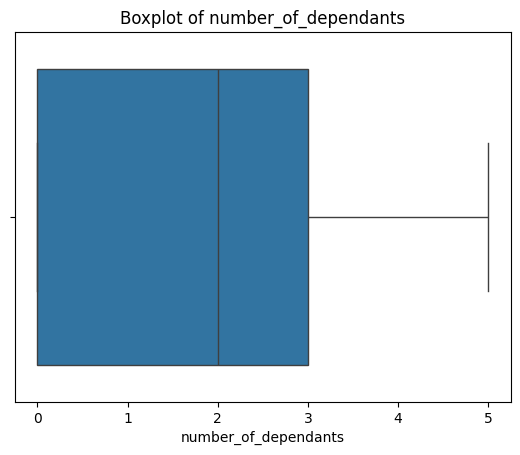

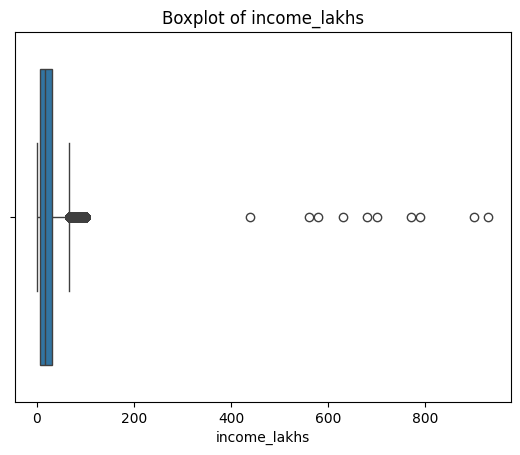

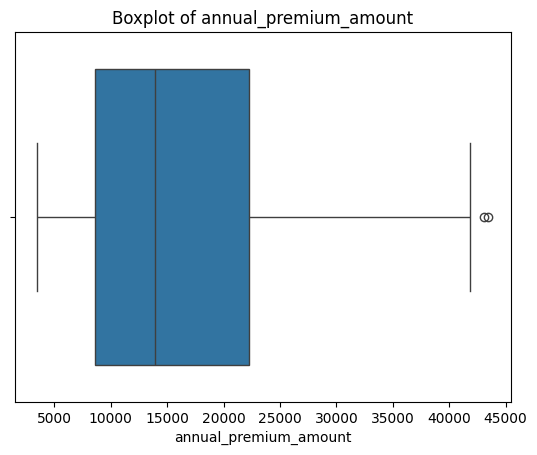

In [87]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [88]:
df[df.age>100]['age'].unique()

array([224, 124, 136, 203, 356])

In [89]:
df1 = df[df.age<=100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.717617,23.025141,15766.589286
std,13.681600,1.492074,24.227912,8419.137327
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


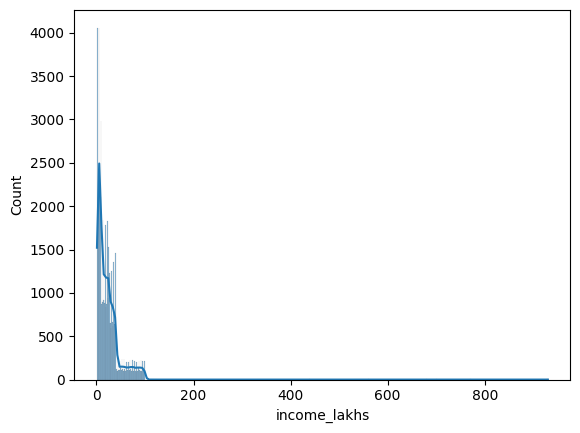

In [91]:
sns.histplot(df1.income_lakhs, kde=True)
plt.show()

In [92]:
df1.income_lakhs.quantile([0.25, 0.75])


0.25     7.0
0.75    31.0
Name: income_lakhs, dtype: float64

In [93]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [94]:
get_iqr_bounds(df1.income_lakhs)

(-29.0, 67.0)

In [95]:
quantile_threshold = df1.income_lakhs.quantile(0.999)
quantile_threshold

np.float64(100.0)

In [96]:
df1[df1.income_lakhs > quantile_threshold].shape

(10, 13)

In [97]:
df2 = df1[df1.income_lakhs <= quantile_threshold].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,22.889897,15765.739641
std,13.681604,1.492032,22.170699,8418.674061
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22270.500000
max,72.000000,5.000000,100.000000,43471.000000


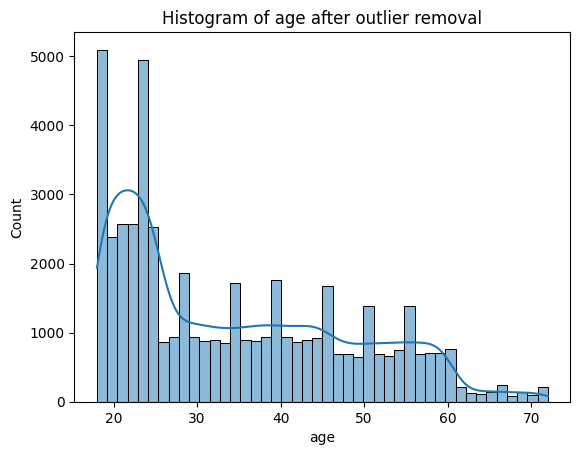

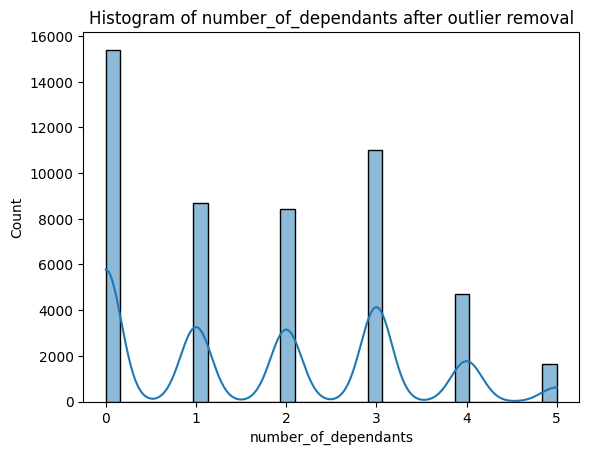

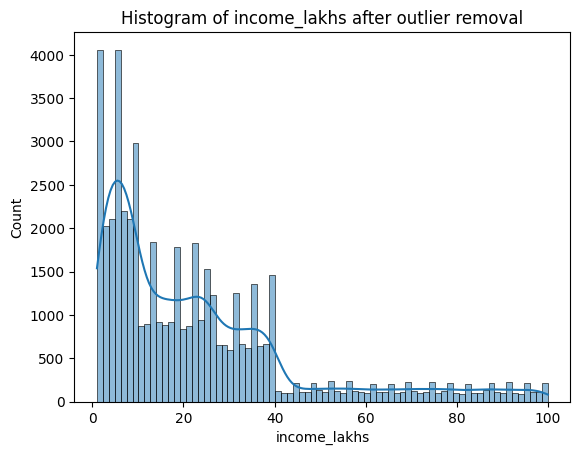

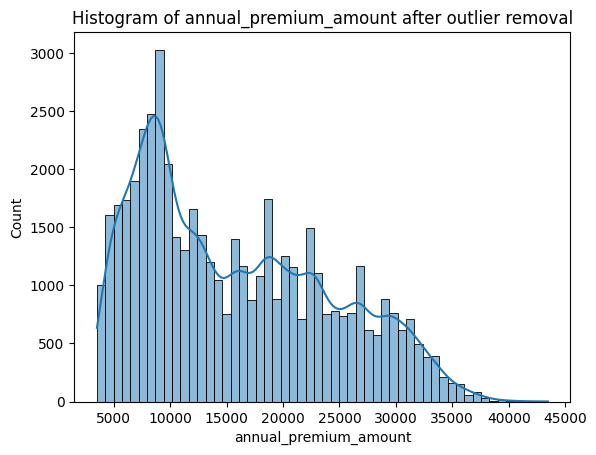

In [98]:

for col in numeric_columns:
    sns.histplot(df2[col], kde=True)
    plt.title(f'Histogram of {col} after outlier removal')
    plt.show()

plt.show()

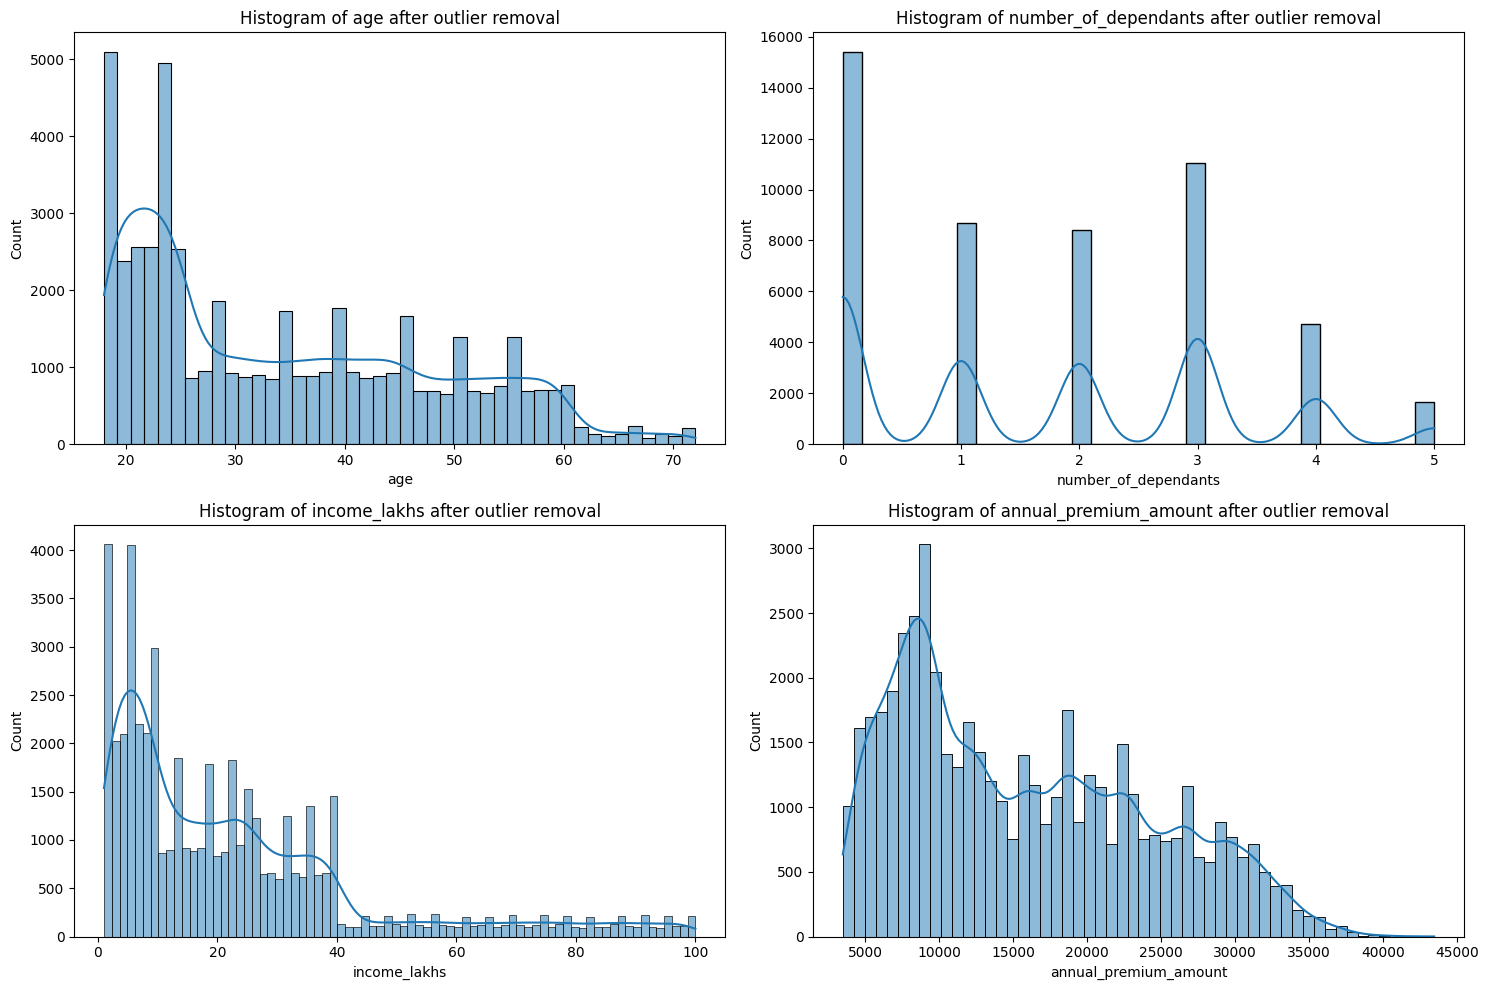

In [99]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    sns.histplot(df2[col], kde=True, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Histogram of {col} after outlier removal')
plt.tight_layout()
plt.show()

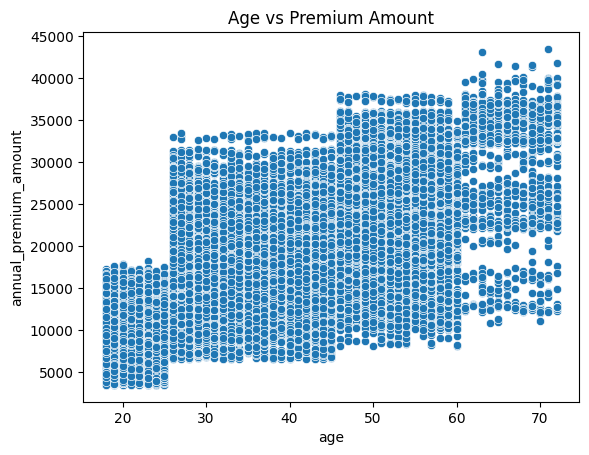

In [100]:
sns.scatterplot(x=df2['age'], y=df2['annual_premium_amount'])
plt.title('Age vs Premium Amount')
plt.show()

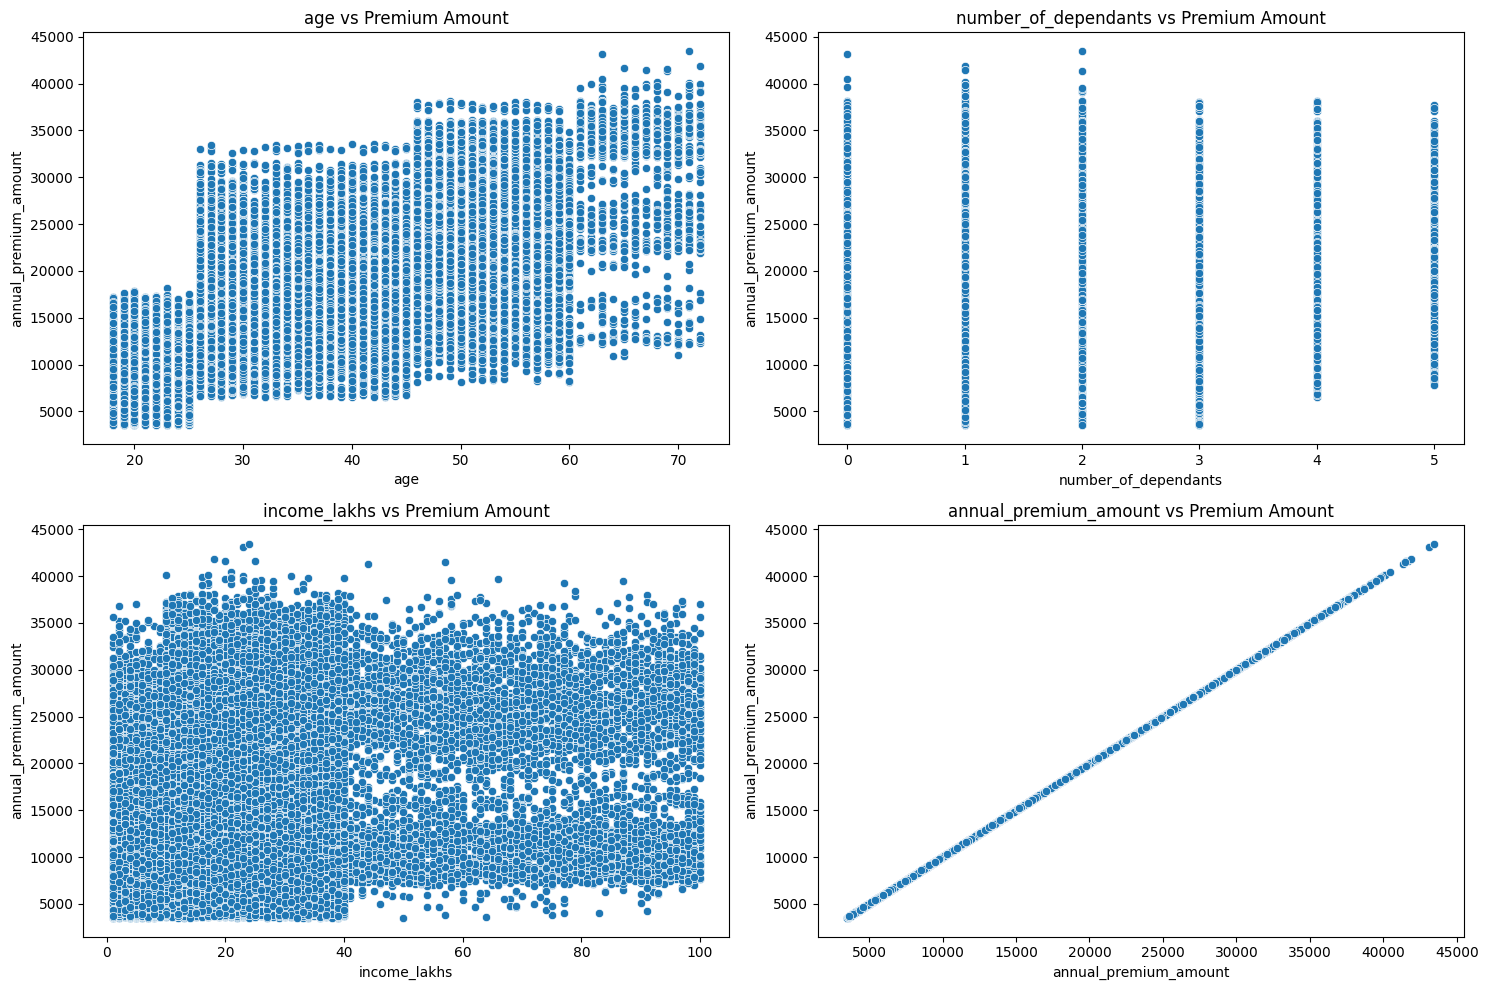

In [101]:
# two layouts for scatter plots
numeric_columns = df2.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    sns.scatterplot(x=df2[col], y=df2['annual_premium_amount'], ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'{col} vs Premium Amount')
plt.tight_layout()
plt.show()


In [102]:
categorical_columns = df2.select_dtypes(include='object').columns
for col in categorical_columns:
    print(f'Value counts for {col}:')
    print(df2[col].unique())

Value counts for gender:
['Male' 'Female']
Value counts for region:
['Northwest' 'Southeast' 'Northeast' 'Southwest']
Value counts for marital_status:
['Unmarried' 'Married']
Value counts for bmi_category:
['Normal' 'Obesity' 'Overweight' 'Underweight']
Value counts for smoking_status:
['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
Value counts for employment_status:
['Salaried' 'Self-Employed' 'Freelancer']
Value counts for income_level:
['<10L' '10L - 25L' '> 40L' '25L - 40L']
Value counts for medical_history:
['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
Value counts for insurance_plan:
['Bronze' 'Silver' 'Gold']


In [103]:
df2['smoking_status'].replace(
    {
        'Smoking=0':'No Smoking',
         'Does Not Smoke':'No Smoking',
         'Not Smoking':'No Smoking',
    },
    inplace=True
)
df2['smoking_status'].unique()

C:\Users\hapatil\AppData\Local\Temp\ipykernel_21600\2684999231.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['smoking_status'].replace(


array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [104]:
ptc_count =df2['gender'].value_counts(normalize=True)
ptc_count

gender
Male      0.549631
Female    0.450369
Name: proportion, dtype: float64

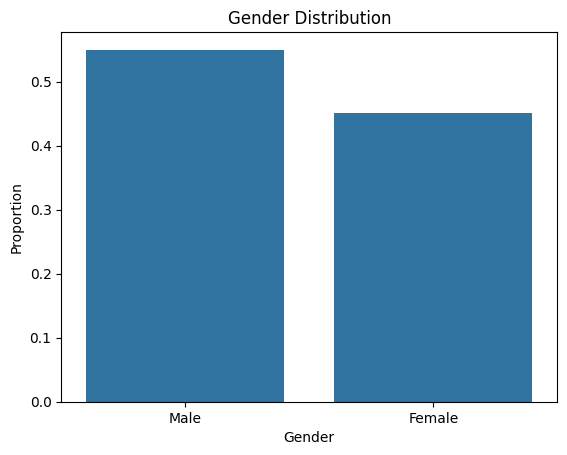

In [105]:
sns.barplot(x=ptc_count.index, y=ptc_count.values)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Proportion')    
plt.show()

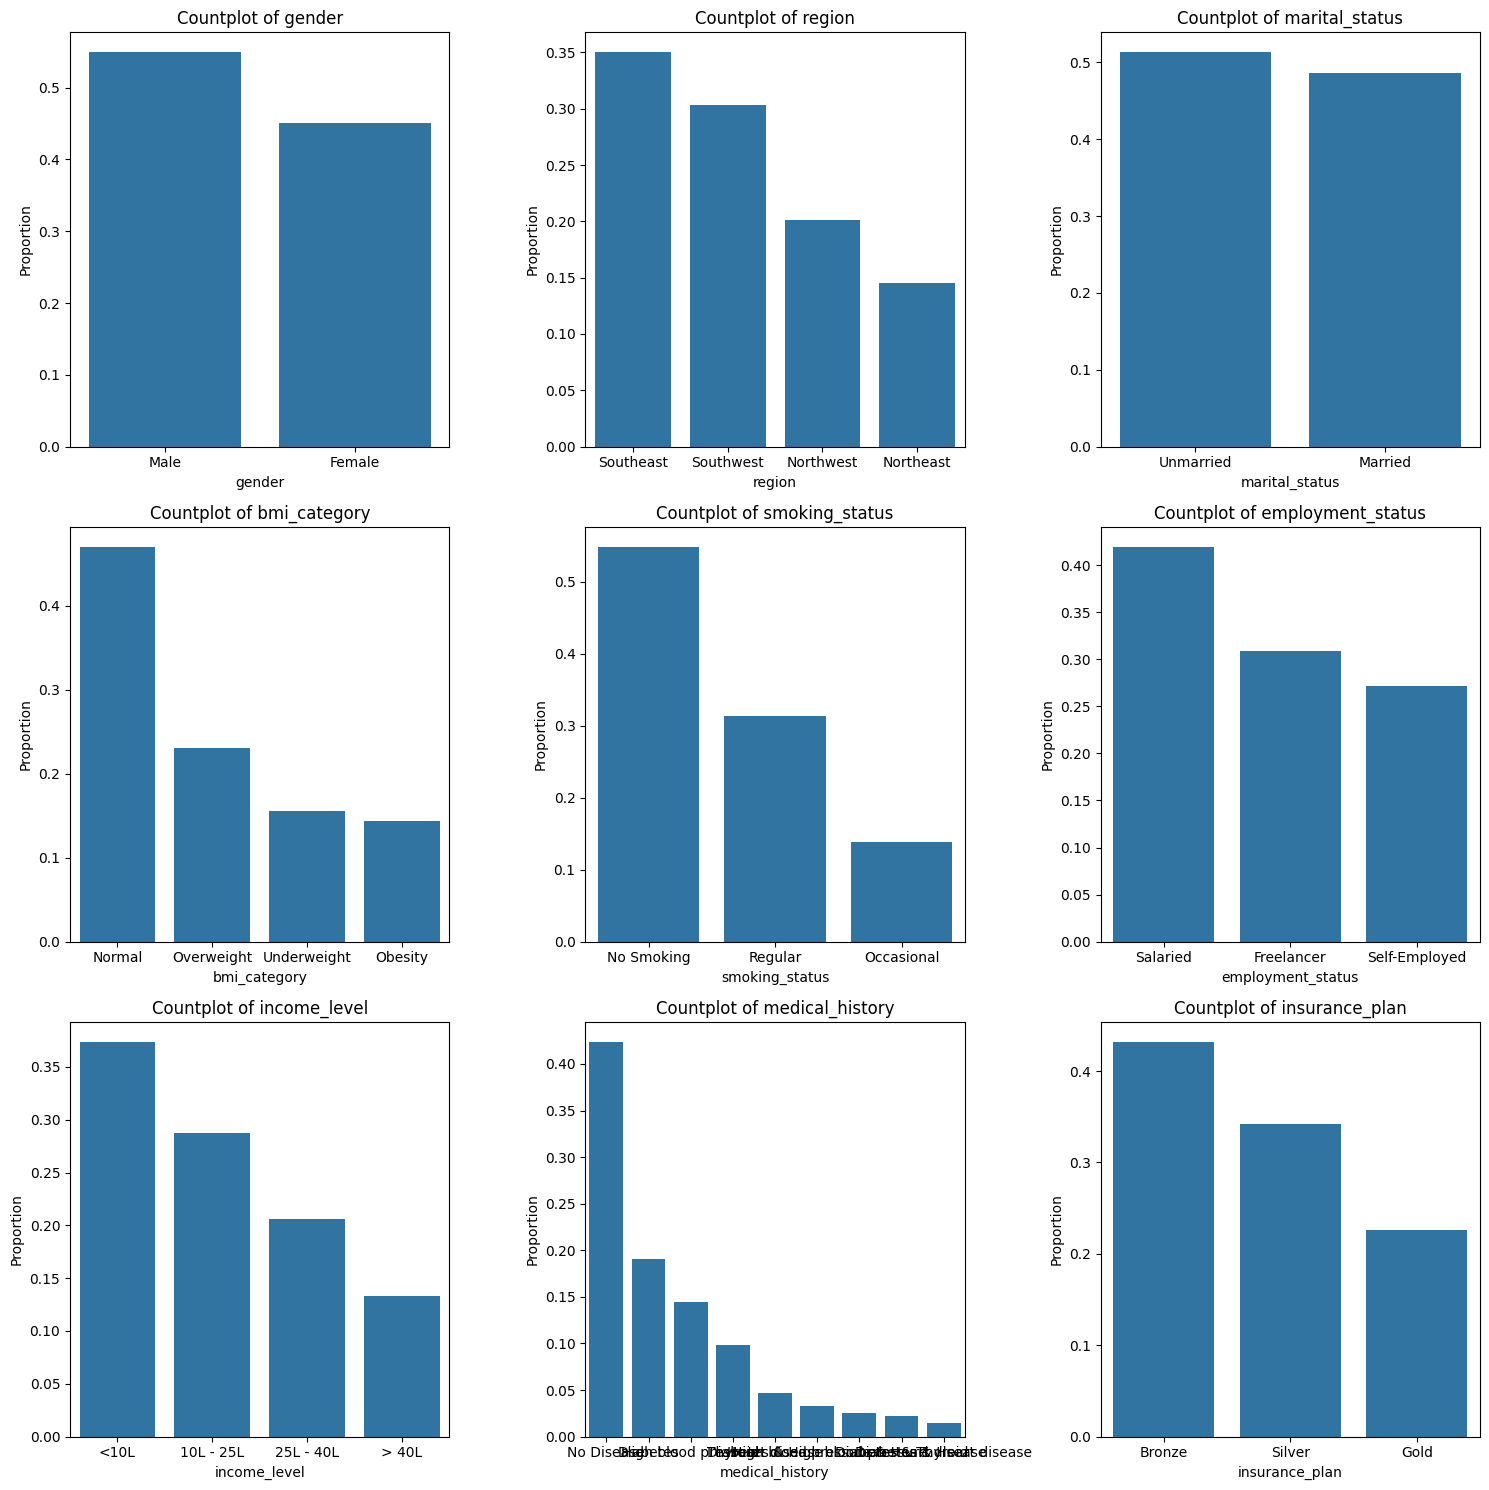

In [106]:
import math

n_plots = len(categorical_columns)
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_columns):
    counts = df2[col].value_counts(normalize=True)
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i])
    axes[i].set_title(f'Countplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')

# Hide any unused subplot axes
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

insurance_plan  Bronze  Gold  Silver
income_range                        
<10L             12226   931    5486
10L-25L           4945  3645    4885
25L-40L           3812  2901    3794
>40L               562  3827    2894


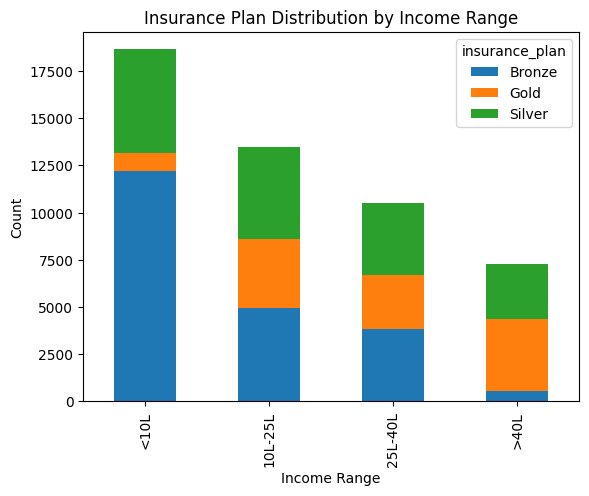

In [108]:
# Create income ranges in lakhs
income_bins = [float('-inf'), 10, 25, 40, float('inf')]
income_labels = ['<10L', '10L-25L', '25L-40L', '>40L']

df2['income_range'] = pd.cut(
    df2['income_lakhs'],
    bins=income_bins,
    labels=income_labels,
    right=False
 )

crosstab = pd.crosstab(df2['income_range'], df2['insurance_plan'])
print(crosstab)

crosstab.plot(kind='bar', stacked=True)
plt.title('Insurance Plan Distribution by Income Range')
plt.xlabel('Income Range')
plt.ylabel('Count')
plt.show()

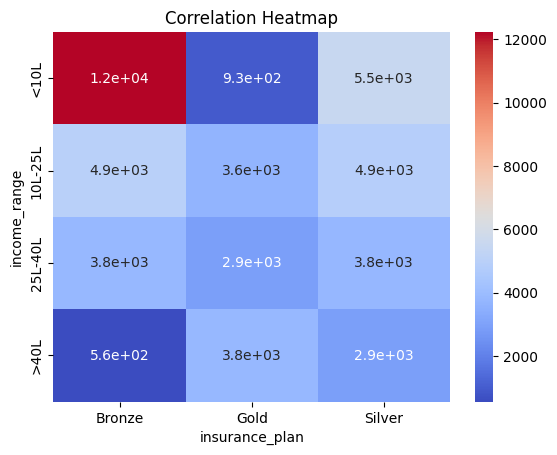

In [109]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')    
plt.show()

In [110]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,<10L
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,<10L
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,10L-25L
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,>40L
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,>40L


In [111]:
df2.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [112]:
risk_scores = {
    "diabetes": 6, 
    "high blood pressure": 6, 
    "no disease": 0,
    "thyroid": 5, 
    "heart disease": 8,
    "none": 0       
}

In [113]:
df2[["disease1","disease2"]] = df2.medical_history.str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,<10L,diabetes,None
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,<10L,diabetes,None
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,10L-25L,high blood pressure,None
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,>40L,no disease,None
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,>40L,high blood pressure,None


In [116]:
df2['disease1'].fillna('none', inplace=True)
df2['disease2'].fillna('none', inplace=True)

df2['total_risk_score'] = 0

for disease_col in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease_col].map(risk_scores)

max_risk_score = df2['total_risk_score'].max()
min_risk_score = df2['total_risk_score'].min()
df2['normalized_risk_score'] = (df2['total_risk_score'] - min_risk_score) / (max_risk_score - min_risk_score)
df2.head(5)

C:\Users\hapatil\AppData\Local\Temp\ipykernel_21600\3450494256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['disease1'].fillna('none', inplace=True)
C:\Users\hapatil\AppData\Local\Temp\ipykernel_21600\3450494256.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,<10L,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,<10L,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,10L-25L,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,>40L,no disease,none,0,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,>40L,high blood pressure,none,6,0.428571


In [117]:
df2.insurance_plan.unique()

array(['Bronze', 'Silver', 'Gold'], dtype=object)

In [118]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})
df2.head()
df2['insurance_plan'].unique()

array([1, 2, 3])

In [119]:
df2['income_level'].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [120]:
df2['income_level'] = df2['income_level'].map({'<10L': 1, '10L - 25L': 2, '25L - 40L': 3, '> 40L': 4})
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,1,6,Diabetes,1,9053,<10L,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,1,6,Diabetes,1,16339,<10L,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,2,20,High blood pressure,2,18164,10L-25L,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,4,77,No Disease,3,20303,>40L,no disease,none,0,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,4,99,High blood pressure,2,13365,>40L,high blood pressure,none,6,0.428571


In [121]:
nominal_cols = ['gender', 'region','marital_status','bmi_category','smoking_status', 'employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)

In [122]:
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,income_range,disease1,disease2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,<10L,diabetes,none,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,<10L,diabetes,none,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,10L-25L,high blood pressure,none,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,>40L,no disease,none,...,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,High blood pressure,2,13365,>40L,high blood pressure,none,...,0,0,1,0,1,0,0,1,0,1


In [123]:
df4 = df3.drop(columns=['disease1', 'disease2', 'total_risk_score', 'medical_history', 'income_range'],axis=1)
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


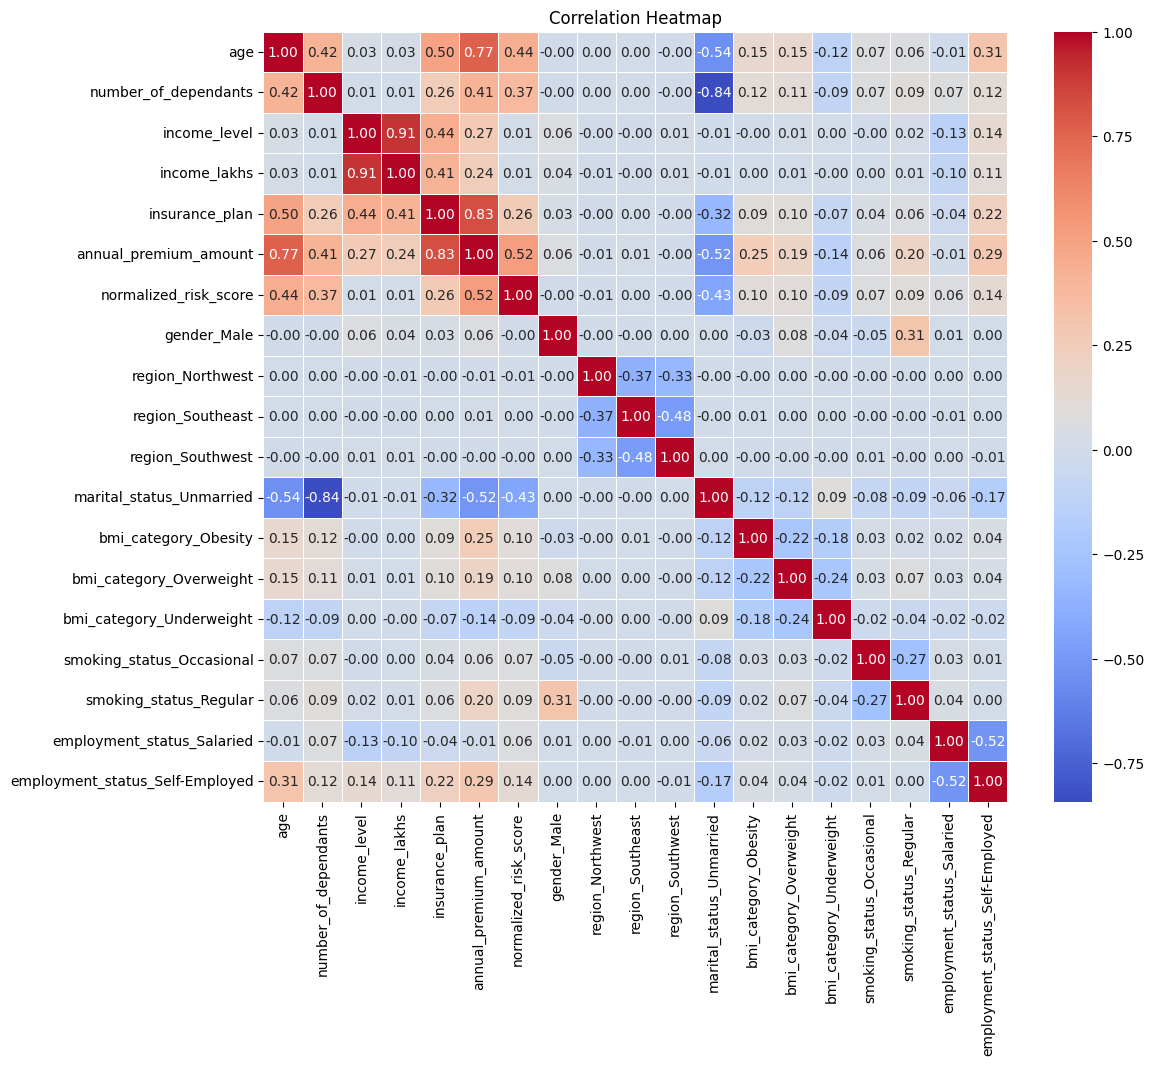

In [124]:
cm = df4.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [125]:
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


In [127]:
y = df4['annual_premium_amount']
X = df4.drop(columns=['annual_premium_amount'], axis='columns')

from sklearn.preprocessing import MinMaxScaler
columns_to_scale = ['age', 'number_of_dependants', 'income_level', 'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()
X[columns_to_scale] = scaler.fit_transform(X[columns_to_scale])
X.head()



,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.000000,0.050505,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.000000,0.050505,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.333333,0.191919,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,1.000000,0.767677,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,1.000000,0.989899,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


In [128]:
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.00000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,0.303733,0.343528,0.365900,0.221110,0.397401,0.291831,0.549631,0.20093,0.350385,0.303038,0.513545,0.143183,0.231245,0.155326,0.138274,0.313857,0.419412,0.272041
std,0.253363,0.298406,0.349711,0.223946,0.392459,0.287420,0.497536,0.40070,0.477095,0.459576,0.499822,0.350263,0.421633,0.362219,0.345191,0.464064,0.493468,0.445015
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.074074,0.000000,0.000000,0.060606,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.240741,0.400000,0.333333,0.161616,0.500000,0.357143,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.600000,0.666667,0.303030,0.500000,0.428571,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [129]:
from  statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['Column'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

In [130]:
calculate_vif(X)

,Column,VIF
0,age,4.567634
1,number_of_dependants,4.534650
2,income_level,12.450675
3,income_lakhs,11.183367
4,insurance_plan,3.584752
5,normalized_risk_score,2.687610
6,gender_Male,2.421496
7,region_Northwest,2.102556
8,region_Southeast,2.922414
9,region_Southwest,2.670666


In [131]:
calculate_vif(X.drop(columns=['income_level'], axis='columns'))

,Column,VIF
0,age,4.545825
1,number_of_dependants,4.526598
2,income_lakhs,2.480563
3,insurance_plan,3.445682
4,normalized_risk_score,2.687326
5,gender_Male,2.409980
6,region_Northwest,2.100789
7,region_Southeast,2.919775
8,region_Southwest,2.668314
9,marital_status_Unmarried,3.393718


In [132]:
X_reduced = X.drop(columns=['income_level'], axis='columns')
X_reduced.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.050505,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.050505,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.191919,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,0.767677,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,0.989899,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


### Model training

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)    
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (34935, 17)
X_test shape: (14973, 17)
y_train shape: (34935,)
y_test shape: (14973,)


In [134]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)
print("Test model score:", model_lr.score(X_test, y_test))
print("Train model score:", model_lr.score(X_train, y_train))

Mean Squared Error (MSE): 5056639.130347775
Root Mean Squared Error (RMSE): 2248.6972073509087
R-squared (R2): 0.9283765993531428
Test model score: 0.9283765993531428
Train model score: 0.9280957176093705


In [135]:
model_lr.coef_

array([11236.4082633 ,  -536.61172956,  -353.97067084, 12515.43782972,
        4846.88626348,   121.53023031,   -34.50219135,    27.97504587,
         -23.47372614,  -821.78088646,  3356.07750448,  1613.1421694 ,
         364.31350886,   722.41051531,  2261.97816483,   149.57179545,
         378.25130285])

In [137]:
feature_importances = model_lr.coef_ 
coef_df = pd.DataFrame(feature_importances, index=X_reduced.columns, columns=['Coefficients'])
coef_df.sort_values(by='Coefficients',  ascending=True, inplace=True)
print(coef_df)

                                 Coefficients
marital_status_Unmarried          -821.780886
number_of_dependants              -536.611730
income_lakhs                      -353.970671
region_Northwest                   -34.502191
region_Southwest                   -23.473726
region_Southeast                    27.975046
gender_Male                        121.530230
employment_status_Salaried         149.571795
bmi_category_Underweight           364.313509
employment_status_Self-Employed    378.251303
smoking_status_Occasional          722.410515
bmi_category_Overweight           1613.142169
smoking_status_Regular            2261.978165
bmi_category_Obesity              3356.077504
normalized_risk_score             4846.886263
age                              11236.408263
insurance_plan                   12515.437830


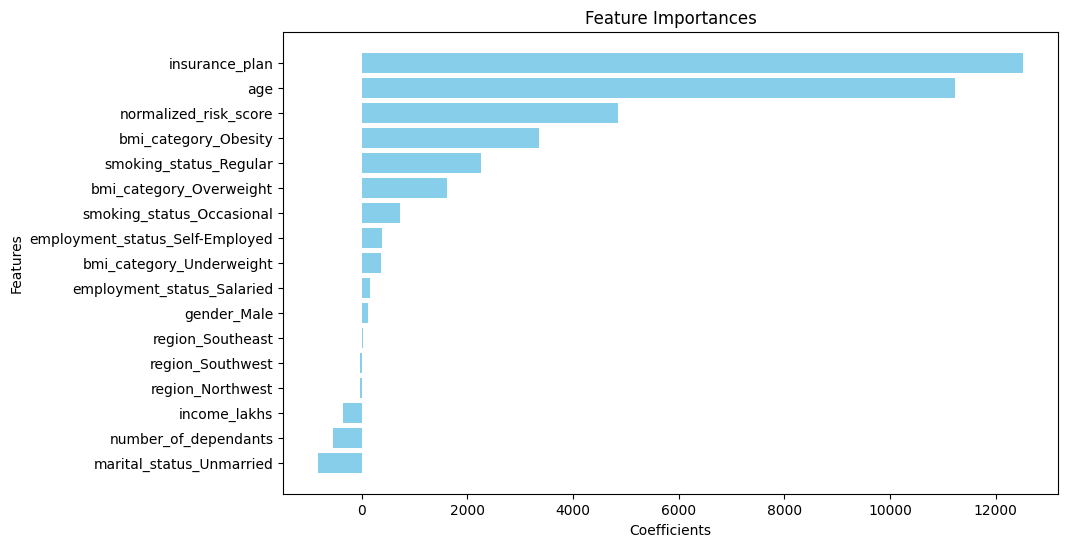

In [138]:

plt.figure(figsize=(10, 6))
plt.barh(coef_df.index, coef_df['Coefficients'], color='skyblue')
plt.xlabel("Coefficients")
plt.ylabel("Features")
plt.title("Feature Importances")
plt.show()

In [139]:
model_rg = Ridge(alpha=1.0)
model_rg.fit(X_train, y_train)

y_pred_rg = model_rg.predict(X_test)
mse_rg = mean_squared_error(y_test, y_pred_rg)
rmse_rg = np.sqrt(mse_rg)
r2_rg = r2_score(y_test, y_pred_rg)

print("Ridge Regression Mean Squared Error (MSE):", mse_rg)
print("Ridge Regression Root Mean Squared Error (RMSE):", rmse_rg)
print("Ridge Regression R-squared (R2):", r2_rg)
print("Ridge Regression Test model score:", model_rg.score(X_test, y_test))
print("Ridge Regression Train model score:", model_rg.score(X_train, y_train))

Ridge Regression Mean Squared Error (MSE): 5056646.815407014
Ridge Regression Root Mean Squared Error (RMSE): 2248.698916130618
Ridge Regression R-squared (R2): 0.9283764905001946
Ridge Regression Test model score: 0.9283764905001946
Ridge Regression Train model score: 0.9280956798900619


In [140]:
from xgboost import XGBRegressor
model_xg = XGBRegressor(random_state=42)
model_xg.fit(X_train, y_train)

y_pred_xg = model_xg.predict(X_test)
mse_xg = mean_squared_error(y_test, y_pred_xg)
rmse_xg = np.sqrt(mse_xg)
r2_xg = r2_score(y_test, y_pred_xg)

print("XGBoost Regression Mean Squared Error (MSE):", mse_xg)
print("XGBoost Regression Root Mean Squared Error (RMSE):", rmse_xg)
print("XGBoost Regression R-squared (R2):", r2_xg)
print("XGBoost Regression Test model score:", model_xg.score(X_test, y_test))
print("XGBoost Regression Train model score:", model_xg.score(X_train, y_train))

XGBoost Regression Mean Squared Error (MSE): 1356363.0
XGBoost Regression Root Mean Squared Error (RMSE): 1164.6299841580587
XGBoost Regression R-squared (R2): 0.9807881712913513
XGBoost Regression Test model score: 0.9807881712913513
XGBoost Regression Train model score: 0.9860933423042297


In [141]:
# Compatibility patch for sklearn 1.6 + older xgboost wrappers
from sklearn.base import RegressorMixin
from sklearn.utils._tags import Tags, TargetTags, RegressorTags

def _patched_sklearn_tags(self):
    return Tags(
        estimator_type='regressor',
        target_tags=TargetTags(required=True),
        regressor_tags=RegressorTags(),
    )

RegressorMixin.__sklearn_tags__ = _patched_sklearn_tags

model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}
random_search = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=1
)
random_search.fit(X_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.1}
0.9816485285758972


In [142]:
best_model = random_search.best_estimator_

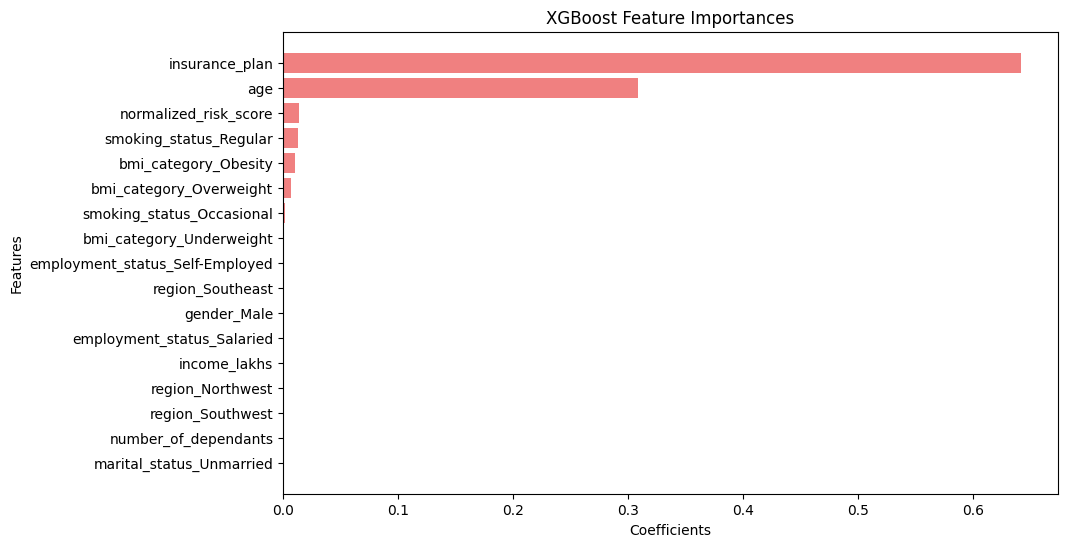

In [143]:
frature_importances = best_model.feature_importances_
coef_df_xgb = pd.DataFrame(frature_importances, index=X_reduced.columns, columns=['Coefficients'])
coef_df_xgb.sort_values(by='Coefficients', ascending=True, inplace=True)

plt.figure(figsize=(10, 6))
plt.barh(coef_df_xgb.index, coef_df_xgb['Coefficients'], color='lightcoral')
plt.xlabel("Coefficients")
plt.ylabel("Features")
plt.title("XGBoost Feature Importances")
plt.show()

### Error Analysis

In [144]:
y_pred_xgb = best_model.predict(X_test)

residuals = y_test - y_pred_xgb
residuals_pct = residuals*100 / y_test

residuals_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_xgb,
    'Residuals': residuals,
    'Residuals (%)': residuals_pct
})
residuals_df.head(10)

,Actual,Predicted,Residuals,Residuals (%)
24098,9246,9176.132812,69.867188,0.755648
201,11664,13535.777344,-1871.777344,-16.047474
25471,10472,7388.482910,3083.517090,29.445350
32500,26267,25723.843750,543.156250,2.067828
30832,9106,9176.132812,-70.132812,-0.770182
11631,15230,15653.842773,-423.842773,-2.782947
12814,16509,16308.230469,200.769531,1.216122
33373,19985,19520.015625,464.984375,2.326667
5408,12340,11957.919922,382.080078,3.096273
47939,11996,13372.326172,-1376.326172,-11.473209


<Axes: xlabel='Residuals (%)', ylabel='Count'>

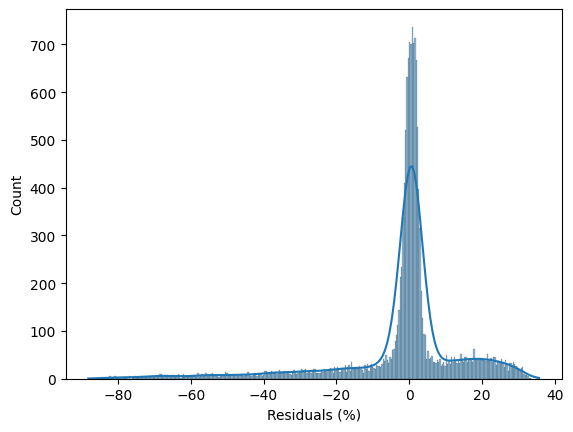

In [ ]:
sns.histplot(residuals_df['Residuals (%)'], kde=True)

In [149]:
extreme_error_threshold = 10
extreme_results_df = residuals_df[np.abs(residuals_df['Residuals (%)']) > extreme_error_threshold]
extreme_results_df.shape

(4392, 4)

In [151]:
extreme_error_percentage = extreme_results_df.shape[0]*100 / residuals_df.shape[0]
extreme_error_percentage

29.332799038268885

In [161]:
residuals_df[np.abs(residuals_df['Residuals (%)']) > 50].sort_values(by='Residuals (%)', ascending=False).head(10)

,Actual,Predicted,Residuals,Residuals (%)
37098,4275,6415.782715,-2140.782715,-50.076789
2513,4375,6568.920898,-2193.920898,-50.146763
32900,4832,7255.901855,-2423.901855,-50.163532
3983,4259,6397.371094,-2138.371094,-50.208291
16988,4973,7470.176758,-2497.176758,-50.214695
5247,4788,7192.940918,-2404.940918,-50.228507
9849,4311,6477.464844,-2166.464844,-50.254346
9979,4725,7102.850098,-2377.850098,-50.324870
30674,4839,7274.644531,-2435.644531,-50.333634
49220,4343,6530.860840,-2187.860840,-50.376717


In [162]:
X_test.index

Index([24098,   201, 25471, 32500, 30832, 11631, 12814, 33373,  5408, 47939,
       ...
        7746, 25417,  8104, 11125,   679, 12123, 31891,  6713, 16957, 15109],
      dtype='int64', length=14973)

In [163]:
extreme_results_df.index

Index([  201, 25471, 47939, 26239, 16907,  5849, 25369,  8403, 38677, 32319,
       ...
        1521, 23789, 24121,  4068, 41535, 21893, 37321, 43822,  7746, 15109],
      dtype='int64', length=4392)

In [165]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
201,0.129630,0.2,0.636364,1.0,0.0,0,1,0,0,1,0,0,0,0,0,0,0
25471,0.074074,0.0,0.010101,0.0,0.0,1,1,0,0,1,0,1,0,0,1,1,0
47939,0.111111,0.0,0.424242,1.0,0.0,0,1,0,0,1,0,0,1,0,0,1,0
26239,0.037037,0.0,0.292929,0.0,0.0,1,1,0,0,1,0,0,1,0,0,0,0
16907,0.111111,0.0,0.606061,0.5,0.0,1,0,0,0,1,0,0,1,0,1,0,0


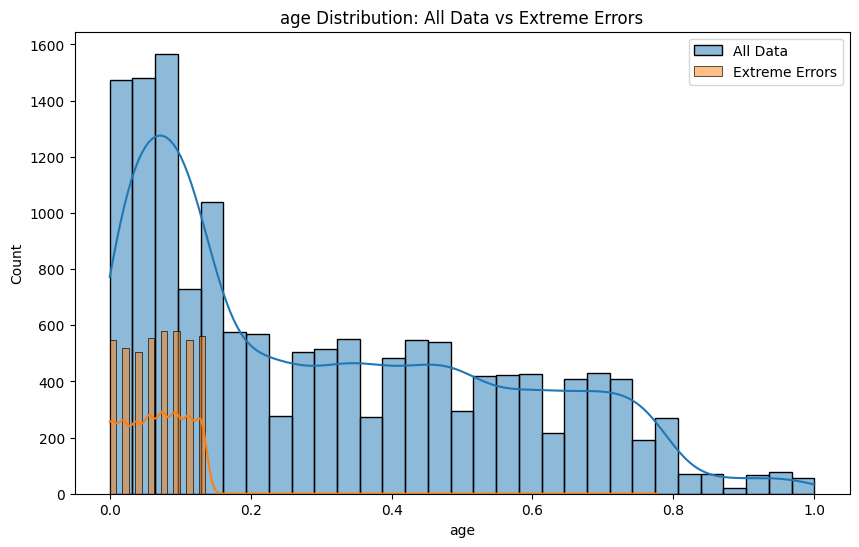

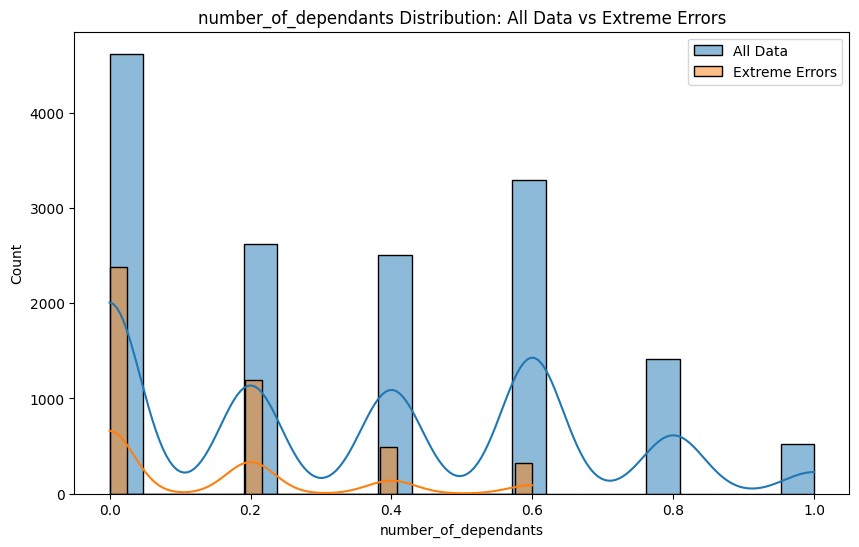

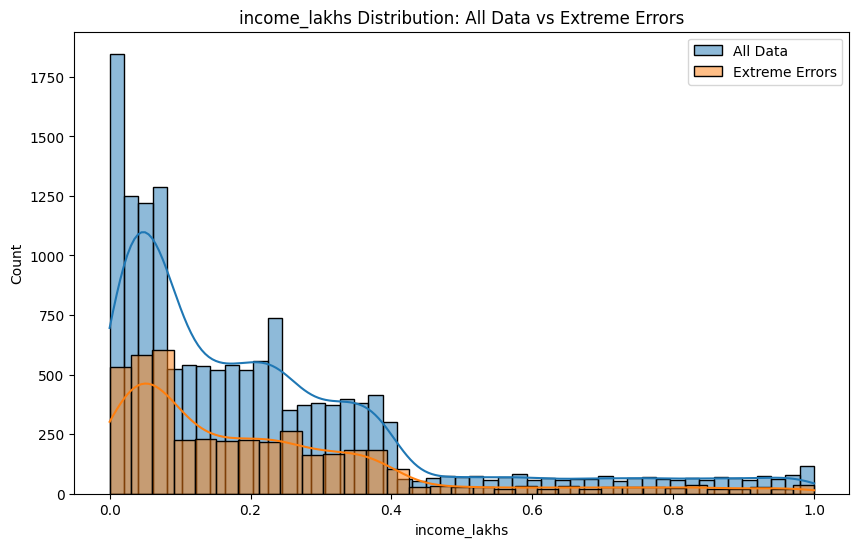

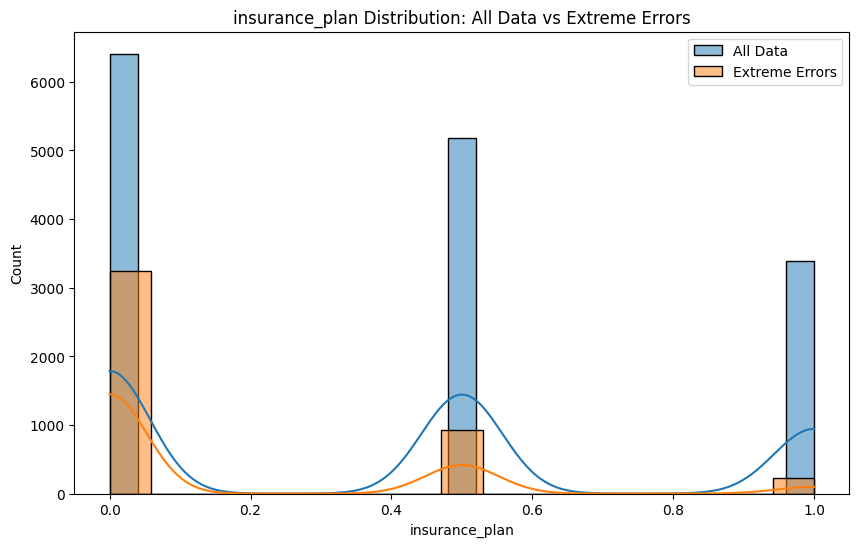

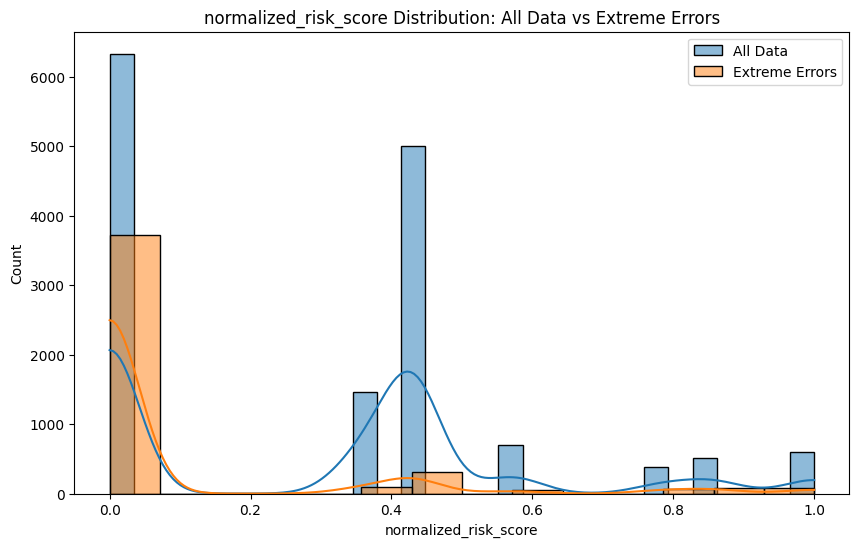

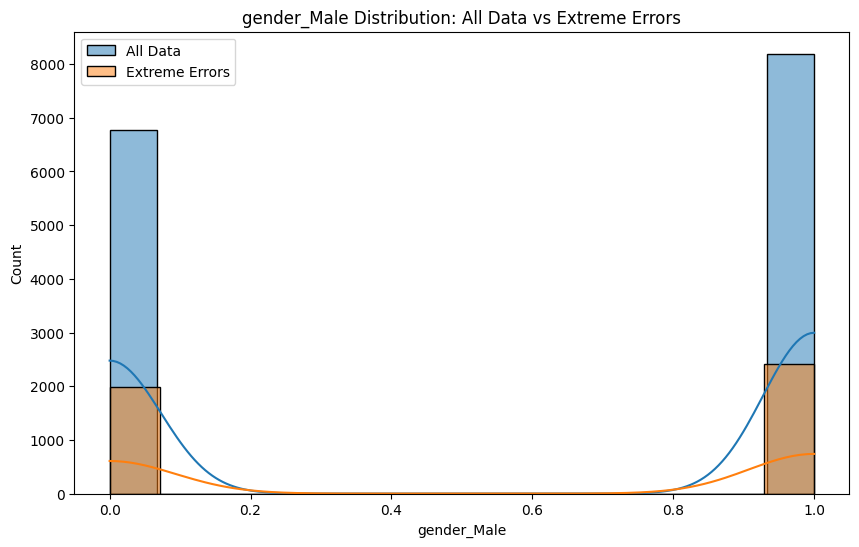

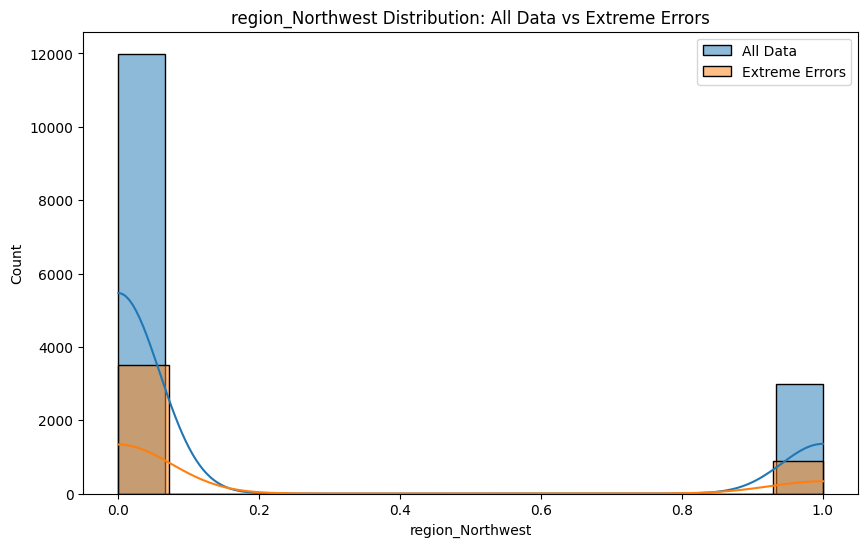

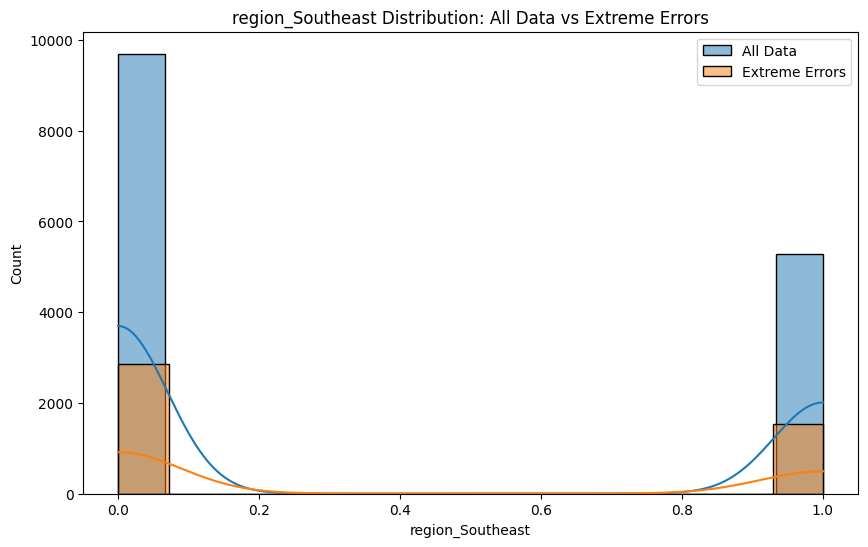

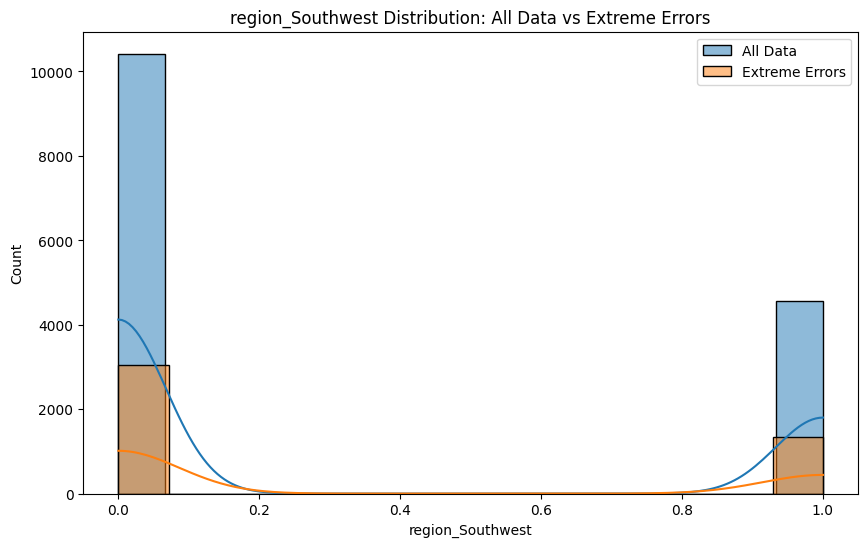

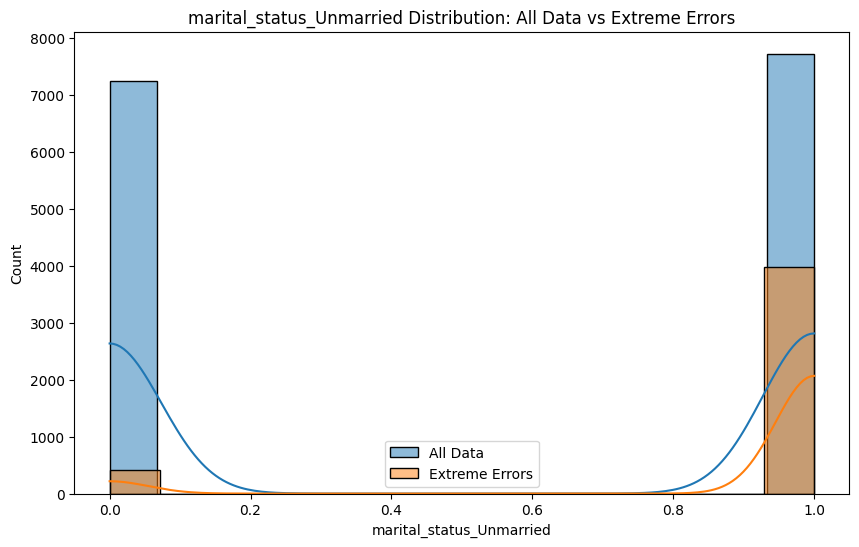

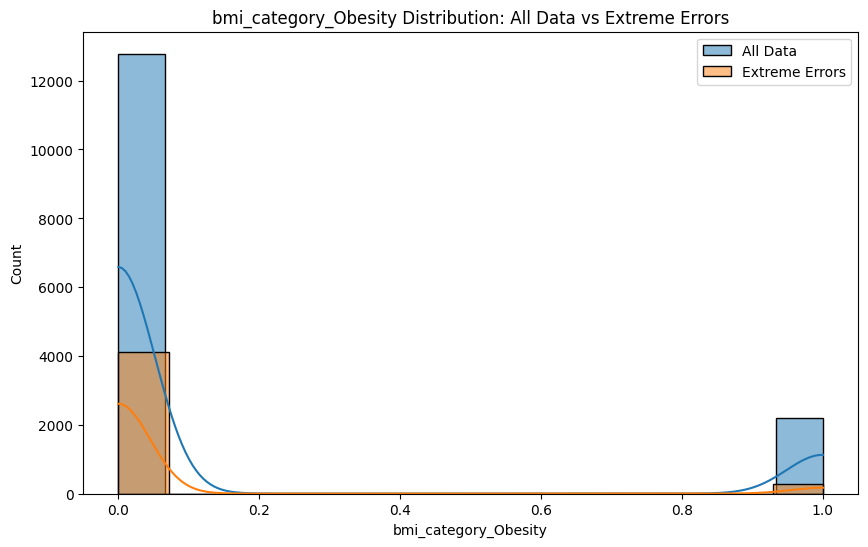

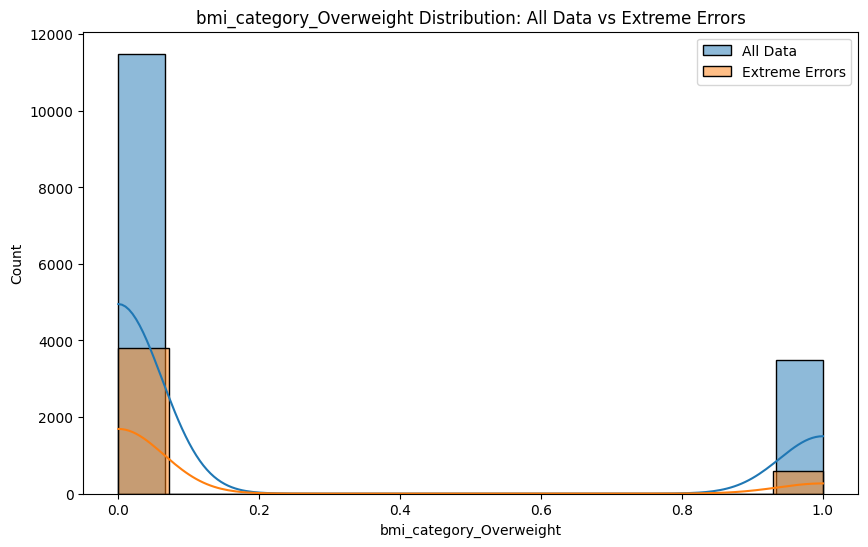

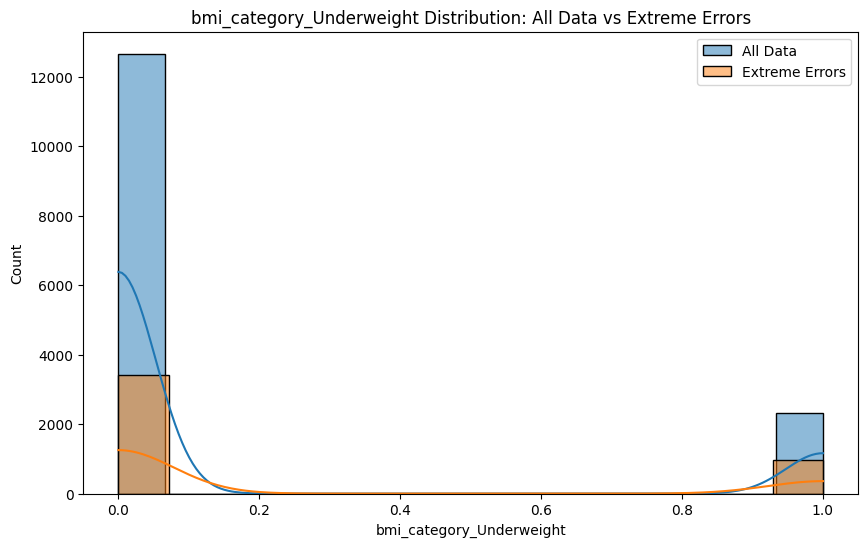

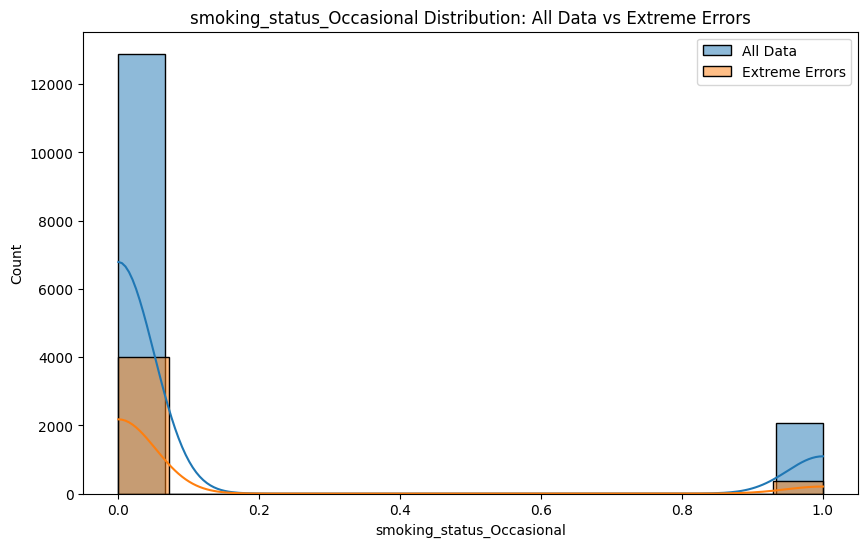

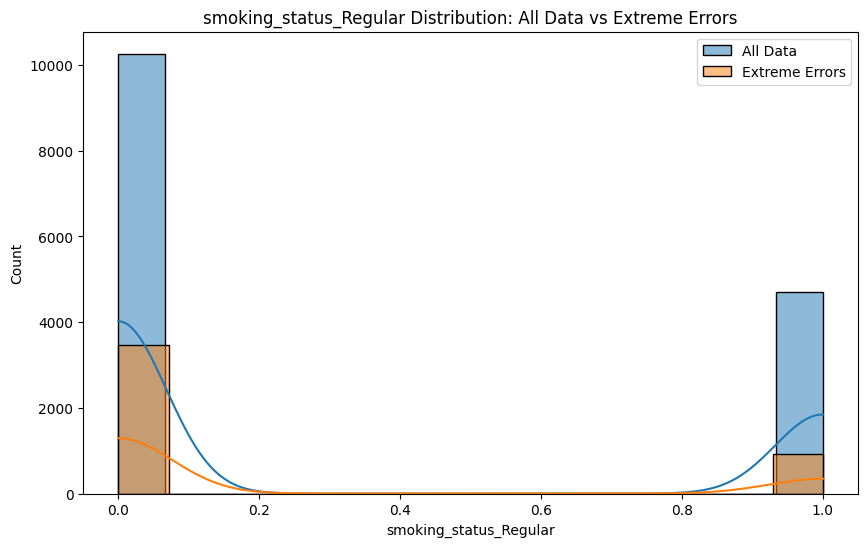

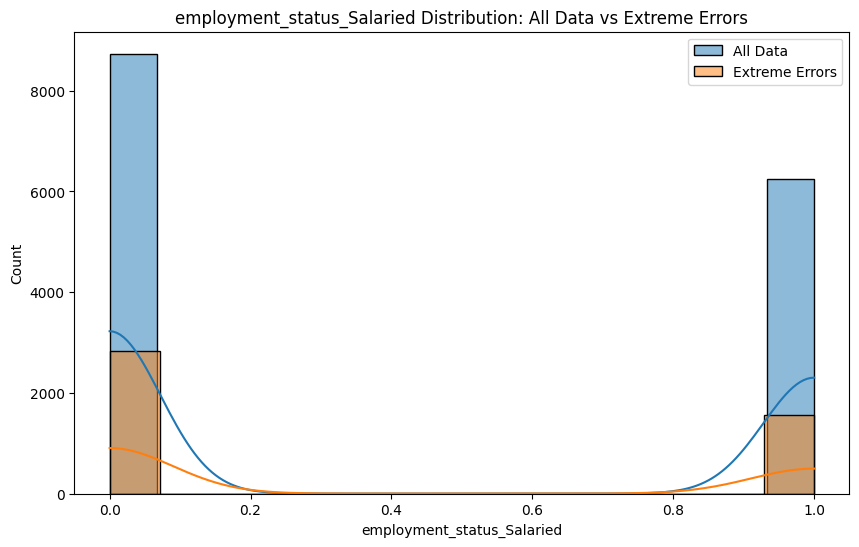

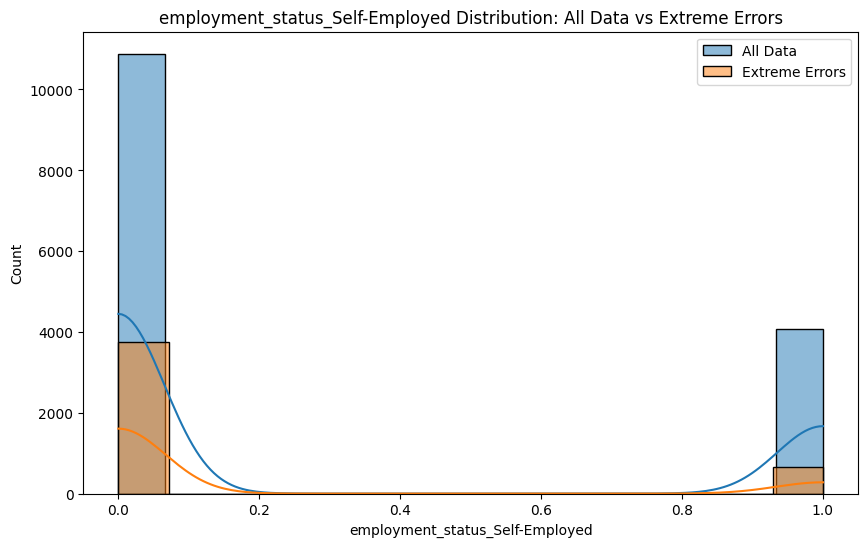

In [168]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(X_test[feature], label='All Data', kde=True)
    sns.histplot(extreme_errors_df[feature], label='Extreme Errors', kde=True)
    plt.legend()
    plt.title(f'{feature} Distribution: All Data vs Extreme Errors')
    plt.show()

In [174]:
cols_to_scale = ['age', 'number_of_dependants', 'income_level', 'income_lakhs', 'insurance_plan']

In [181]:
extreme_errors_df['income_level'] = -1

<Axes: xlabel='age', ylabel='Count'>

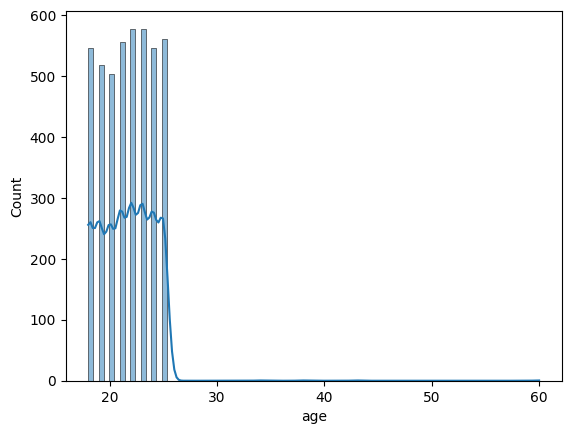

In [183]:
df_reversed = pd.DataFrame() 
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])

df_reversed

sns.histplot(df_reversed['age'], kde=True)

In [185]:
df_reversed['age'].quantile(0.97)

np.float64(25.0)